# Numerical Simulation Laboratory - Exercise 03

## INTRODUCTION

### Historical note

The Black-Scholes formula was introduced in 1973 by Fischer Black and Myron Scholes, while Robert Merton independently developed and extended the same continuous-time approach to option pricing. For this reason, the framework is often called the Black-Scholes-Merton model.

Its importance is that it gave a closed analytical expression for the fair price of European options under a set of idealized market assumptions. The formula also made clear the link between option pricing, stochastic processes and the idea of hedging a risky derivative by dynamically trading the underlying asset and a risk-free bond. In 1997, the Nobel Prize in Economic Sciences was awarded to Myron Scholes and Robert Merton for this contribution; Fischer Black had died before the prize was awarded.

### Black-Scholes-Merton model

A European option is a derivative contract that can be exercised only at the maturity time $T$. A European call gives the right to buy the underlying asset at the strike price $K$, while a European put gives the right to sell it at the same strike price. Therefore, their payoffs at maturity are

$$
C_T = \max(0,S(T)-K),
\qquad
P_T = \max(0,K-S(T)).
$$

In the Black-Scholes-Merton model the asset price follows a geometric Brownian motion. Under the risk-neutral measure, the drift is the risk-free interest rate $r$:

$$
dS(t) = rS(t)dt + \sigma S(t)dW(t),
$$

where $\sigma$ is the volatility and $W(t)$ is a standard Brownian motion. The corresponding solution is

$$
S(T)=S(0)\exp\left[\left(r-\frac{\sigma^2}{2}\right)T+\sigma W(T)\right],
\qquad W(T)\sim\mathcal N(0,T).
$$

The option price at time $t=0$ can be interpreted as the **discounted** risk-neutral expectation of the payoff:

$$
C(0)=e^{-rT}\mathbb E\left[\max(0,S(T)-K)\right],
\qquad
P(0)=e^{-rT}\mathbb E\left[\max(0,K-S(T))\right].
$$

The analytical Black-Scholes prices are

$$
C[S(t),t] = S(t)N(d_1)-Ke^{-r(T-t)}N(d_2),
$$

$$
P[S(t),t] = S(t)\left[N(d_1)-1\right]-Ke^{-r(T-t)}\left[N(d_2)-1\right],
$$

with

$$
d_1=\frac{\ln\left(S(t)/K\right)+\left(r+\frac{\sigma^2}{2}\right)(T-t)}{\sigma\sqrt{T-t}},
\qquad
d_2=d_1-\sigma\sqrt{T-t}.
$$

Here $N(x)$ is the cumulative distribution function of a standard normal variable. The quantities $d_1$ and $d_2$ combine the moneyness of the option, the interest rate, the volatility and the time to maturity into dimensionless variables. The model assumes constant $r$ and $\sigma$, no arbitrage, frictionless markets, continuous trading and log-normal asset prices. These assumptions are idealized, but the formula is still a fundamental benchmark for testing Monte Carlo option-pricing algorithms.

## EXERCISE 03.1 - Plain vanilla option pricing

### Assignment prompt

Black-Scholes theory assumes that the time evolution of the asset price is stochastic and exhibits geometric Brownian motion (GBM) with constant risk-free interest rate $r$ and volatility $\sigma$.

Black-Scholes analytic solution for the price at time $t<T$:

- European call-option price:

$$
C\left[S(t),t\right]=S(t)N(d_1)-Ke^{-r(T-t)}N(d_2)
$$

- European put-option price:

$$
P\left[S(t),t\right]=S(t)\left[N(d_1)-1\right]-Ke^{-r(T-t)}\left[N(d_2)-1\right]
$$

where

$$
d_1=\frac{\ln\left(S(t)/K\right)+\left(r+\frac{\sigma^2}{2}\right)(T-t)}{\sigma\sqrt{T-t}},
\qquad
d_2=d_1-\sigma\sqrt{T-t},
$$

and where

$$
N(x)=\frac{1}{2}\left[1+\mathrm{erf}\left(\frac{x}{\sqrt 2}\right)\right]
$$

is the cumulative distribution function of a standard Gaussian variable.

By using the following parameters:

- asset price at $t=0$: $S(0)=100$;
- delivery time: $T=1$;
- strike price: $K=100$;
- risk-free interest rate: $r=0.1$;
- volatility: $\sigma=0.25$;

compute at time $t=0$ via Monte Carlo the European call-option price, $C[S(0),0]$, and put-option price, $P[S(0),0]$:

1. by sampling directly the final asset price $S(T)$ for a $GBM(r,\sigma^2)$;
2. by sampling the discretized $GBM(r,\sigma^2)$ path of the asset price, dividing $[0,T]$ in $10^2$ time intervals.

Make four pictures for the estimation of the European call-option prices, $C[S(0),0]$ direct and discretized, and put-option prices, $P[S(0),0]$ direct and discretized, with their uncertainties, with a large number of asset prices at time $T$, say $M\ge 10^4$, as a function of the number of blocks $N$. As usual, in computing statistical uncertainties, use data blocking.

### Method

The simulation estimates the discounted expectation value of the payoff. For each sampled final asset price $S(T)$, the discounted call and put payoffs are

$$
C=e^{-rT}\max(0,S(T)-K),
\qquad
P=e^{-rT}\max(0,K-S(T)).
$$

The calculation uses $M=10^4$ simulated asset prices divided into $N=100$ blocks. For each block, the mean payoff is computed. The progressive average over the blocks gives the Monte Carlo estimate as a function of the number of blocks, while the statistical uncertainty is obtained with the usual blocking formula.

#### 1) Direct sampling of $S(T)$

For the direct method, the final asset price is sampled in one step from the exact solution of the geometric Brownian motion:

$$
S(T)=S(0)\exp\left[\left(r-\frac{\sigma^2}{2}\right)T+\sigma W(T)\right],
\qquad W(T)\sim\mathcal N(0,T).
$$

This method does not introduce a time-discretization error, because the distribution of $S(T)$ is sampled directly.

#### 2) Discretized GBM path

For the discretized method, the interval $[0,T]$ is divided into $100$ time steps. Starting from $S(0)$, the price is updated recursively as

$$
S(t_{i+1})=S(t_i)\exp\left[\left(r-\frac{\sigma^2}{2}\right)\Delta t + \sigma Z_i\sqrt{\Delta t}\right],
\qquad Z_i\sim\mathcal N(0,1).
$$

This formula comes from the exact solution of the geometric Brownian motion

$$
dS(t)=rS(t)\,dt+\sigma S(t)\,dW(t).
$$

Applying Itô's formula to $\ln S(t)$ gives

$$
d\ln S(t)=\left(r-\frac{\sigma^2}{2}\right)dt+\sigma dW(t).
$$

Integrating this equation between two consecutive times $t_i$ and $t_{i+1}=t_i+\Delta t$ gives

$$
\ln S(t_{i+1})-\ln S(t_i)
=
\left(r-\frac{\sigma^2}{2}\right)\Delta t+\sigma\Delta W_i.
$$

For a standard Brownian motion,

$$
\Delta W_i = W(t_{i+1})-W(t_i)\sim \mathcal N(0,\Delta t),
$$

so it can be written as

$$
\Delta W_i = Z_i\sqrt{\Delta t},
\qquad Z_i\sim\mathcal N(0,1).
$$

Exponentiating the logarithmic relation gives the recursive update used in the simulation.

Since this update is the exact transition law of the GBM over a finite time interval $\Delta t$, the discretized path should give results compatible with the direct method; the only relevant differences should be statistical fluctuations.

### C++ implementation

The C++ code implements the GBM evolution through a compact function:

```cpp
double GBM(double t, double S0, double mu, double sigma, double w) {
    return S0 * exp((mu - 0.5 * sigma * sigma) * t + sigma * w);
}
```

In the direct method, the Brownian increment is sampled directly as $W(T)\sim\mathcal N(0,T)$:

```cpp
double w = rnd.Gauss(0, sqrt(T));
double ST = GBM(T, S_0, r, sigma, w);

double payoff_call = exp(-r * T) * max(0.0, ST - K);
double payoff_put  = exp(-r * T) * max(0.0, K - ST);
```

In the discretized method, the same transition rule is applied repeatedly with $\Delta t=T/100$:

```cpp
double ST = S_0;
for (int t = 0; t < n_steps; t++) {
    double Z = rnd.Gauss(0.0, 1.0);
    ST = GBM(dt, ST, r, sigma, Z * sqrt(dt));
}
```

The block averages are then accumulated progressively and compared with the analytical Black-Scholes values.

### Analytical benchmark

In [5]:
from math import erf, exp, log, sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Model parameters
S0 = 100.0
K = 100.0
T = 1.0
r = 0.1
sigma = 0.25


def N(x):
    """Cumulative distribution function of a standard normal variable."""
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def black_scholes(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    call = S0 * N(d1) - K * exp(-r * T) * N(d2)
    put = S0 * (N(d1) - 1.0) - K * exp(-r * T) * (N(d2) - 1.0)
    return call, put


call_bs, put_bs = black_scholes(S0, K, T, r, sigma)
print(f"Black-Scholes call price = {call_bs:.6f}")
print(f"Black-Scholes put price  = {put_bs:.6f}")

Black-Scholes call price = 14.975791
Black-Scholes put price  = 5.459533


### Monte Carlo results

In [6]:
data = pd.read_csv("Results/Esercizio_03.1_results.txt", sep=";")

N_blocks = len(data)
x = np.arange(1, N_blocks + 1)

final_values = data.iloc[-1]
comparison = pd.DataFrame(
    {
        "Monte Carlo estimate": [
            final_values["Progressive_direct_call"],
            final_values["Progressive_discrete_call"],
            final_values["Progressive_direct_put"],
            final_values["Progressive_discrete_put"],
        ],
        "Statistical uncertainty": [
            final_values["Progressive_direct_call_error"],
            final_values["Progressive_discrete_call_error"],
            final_values["Progressive_direct_put_error"],
            final_values["Progressive_discrete_put_error"],
        ],
        "Black-Scholes benchmark": [call_bs, call_bs, put_bs, put_bs],
    },
    index=["Direct call", "Discretized call", "Direct put", "Discretized put"],
)

comparison["Difference / uncertainty"] = (
    comparison["Monte Carlo estimate"] - comparison["Black-Scholes benchmark"]
) / comparison["Statistical uncertainty"]

comparison

,Monte Carlo estimate,Statistical uncertainty,Black-Scholes benchmark,Difference / uncertainty
Direct call,15.08170,0.213464,14.975791,0.496146
Discretized call,14.96750,0.212919,14.975791,-0.038939
Direct put,5.54663,0.086160,5.459533,1.010881
Discretized put,5.31927,0.091351,5.459533,-1.535420


### Plots

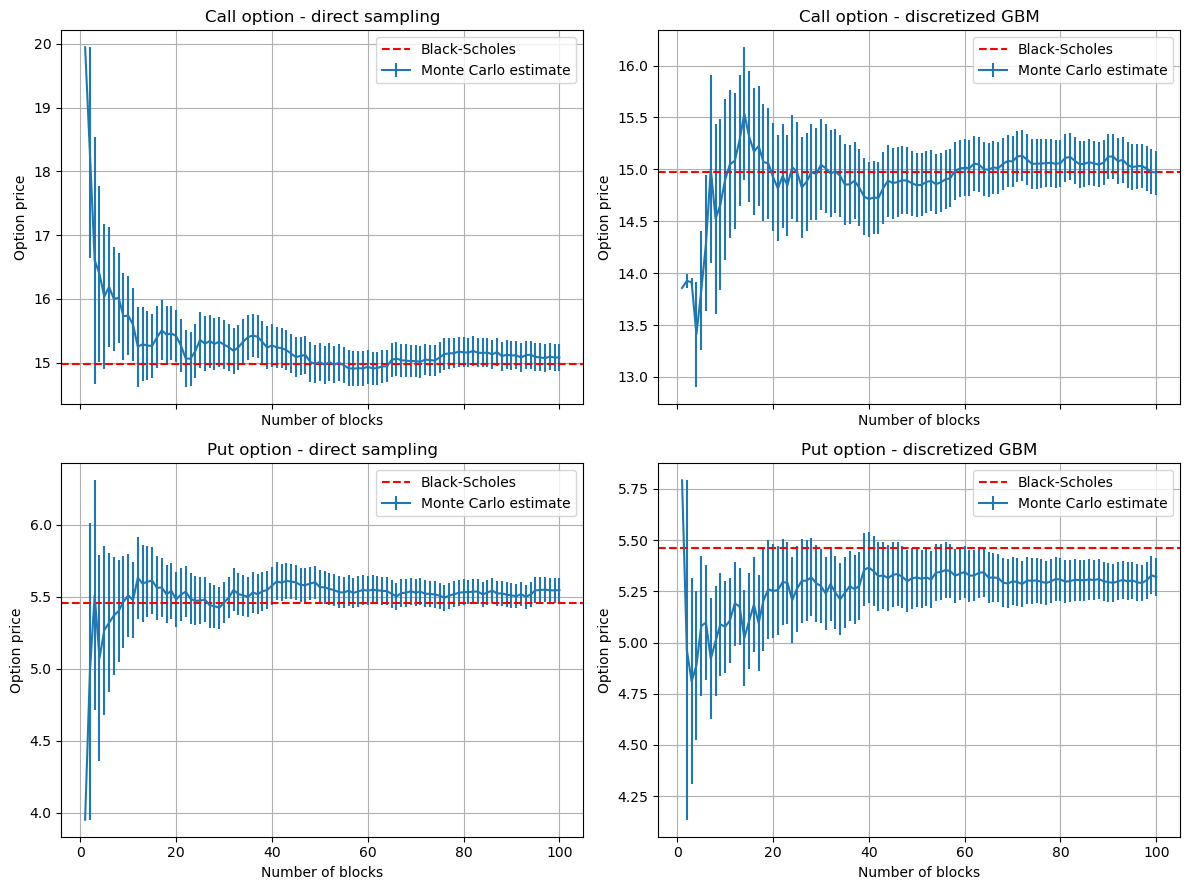

In [7]:
def plot_estimate(ax, x, estimate, uncertainty, benchmark, title, ylabel):
    ax.errorbar(x, estimate, yerr=uncertainty, label="Monte Carlo estimate")
    ax.axhline(benchmark, color="red", linestyle="--", label="Black-Scholes")
    ax.set_title(title)
    ax.set_xlabel("Number of blocks")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()


fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

plot_estimate(
    axs[0, 0],
    x,
    data["Progressive_direct_call"],
    data["Progressive_direct_call_error"],
    call_bs,
    "Call option - direct sampling",
    "Option price",
)

plot_estimate(
    axs[0, 1],
    x,
    data["Progressive_discrete_call"],
    data["Progressive_discrete_call_error"],
    call_bs,
    "Call option - discretized GBM",
    "Option price",
)

plot_estimate(
    axs[1, 0],
    x,
    data["Progressive_direct_put"],
    data["Progressive_direct_put_error"],
    put_bs,
    "Put option - direct sampling",
    "Option price",
)

plot_estimate(
    axs[1, 1],
    x,
    data["Progressive_discrete_put"],
    data["Progressive_discrete_put_error"],
    put_bs,
    "Put option - discretized GBM",
    "Option price",
)

plt.tight_layout()
plt.show()

### Comment

All four Monte Carlo estimates are compatible with the corresponding Black-Scholes analytical prices within the statistical uncertainties. The direct and discretized methods give very similar results, as expected, because the GBM transition probability is known exactly and is used both in the direct final-time sampling and in each step of the discretized path.

The direct call and the discretized call converge to the same benchmark value. The direct put is slightly above the analytical value, while the discretized put is slightly below it, but the deviations are of the order of the final statistical errors. Therefore, the observed differences are consistent with Monte Carlo fluctuations and do not indicate a systematic bias.